# Rec Center Occupancy EDA

This notebook performs EDA on three Occuspace exports:
- `-30minExport-1May23-1May24.csv`
- `-30minExport-1Jun24-1Jun25.csv`
- `-30minExport-1Jun25-15Apr26.csv`

It covers required project components:
1. Dataset description and provenance
2. Number of rows and columns
3. Description of variables
4. Initial exploratory analysis (visuals + summaries)
5. Proposed modeling approach
6. Initial learning goals for each group member

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

BASE = Path.cwd()
if not (BASE / '-30minExport-1Jun24-1Jun25.csv').exists():
    BASE = Path.cwd() / 'ClassProject'

FILES = {
    '2023-05_to_2024-05': '-30minExport-1May23-1May24.csv',
    '2024-06_to_2025-06': '-30minExport-1Jun24-1Jun25.csv',
    '2025-06_to_2026-04': '-30minExport-1Jun25-15Apr26.csv',
}

BASE

PosixPath('/Users/pmazolew/Documents/GitHub/AdvancedMachineLearning/ClassProject')

In [2]:
def load_export(period, filename):
    path = BASE / filename
    # 6 metadata rows at top; row 7 contains actual headers.
    df = pd.read_csv(path, skiprows=6)
    df['export_period'] = period
    df['source_file'] = filename
    return df

frames = [load_export(period, fname) for period, fname in FILES.items()]
df = pd.concat(frames, ignore_index=True)

# Parse time columns
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

numeric_cols = [
    'Day of Week', 'Week of Year', 'Hour of Day',
    'Average Occupancy', 'Average Utilization',
    'Peak Occupancy', 'Peak Utilization', 'Capacity'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df.head()

,Location,Timestamp,Date,Day of Week,Week of Year,Time,Hour of Day,Average Occupancy,Average Utilization,Peak Occupancy,Peak Utilization,Capacity,Location Path,export_period,source_file
0,Lower Exercise Room,2023-05-13 06:00:00,2023-05-13,7,19,6:00:00 AM,6,2,0.02,3,0.04,85,Cal Poly > Rec Center > 1st Floor > Lower Exe...,2023-05_to_2024-05,-30minExport-1May23-1May24.csv
1,Lower Exercise Room,2023-05-13 06:30:00,2023-05-13,7,19,6:30:00 AM,6,2,0.02,3,0.04,85,Cal Poly > Rec Center > 1st Floor > Lower Exe...,2023-05_to_2024-05,-30minExport-1May23-1May24.csv
2,Lower Exercise Room,2023-05-13 07:00:00,2023-05-13,7,19,7:00:00 AM,7,2,0.02,3,0.04,85,Cal Poly > Rec Center > 1st Floor > Lower Exe...,2023-05_to_2024-05,-30minExport-1May23-1May24.csv
3,Lower Exercise Room,2023-05-13 07:30:00,2023-05-13,7,19,7:30:00 AM,7,3,0.04,3,0.04,85,Cal Poly > Rec Center > 1st Floor > Lower Exe...,2023-05_to_2024-05,-30minExport-1May23-1May24.csv
4,Lower Exercise Room,2023-05-13 08:00:00,2023-05-13,7,19,8:00:00 AM,8,10,0.12,15,0.18,85,Cal Poly > Rec Center > 1st Floor > Lower Exe...,2023-05_to_2024-05,-30minExport-1May23-1May24.csv


## 1) Dataset Description and Provenance

- **Source platform:** Occuspace occupancy exports for Cal Poly Rec Center spaces.
- **Collection resolution:** 30-minute intervals.
- **Clock range in export metadata:** 6:00 to 23:30, all days of week.
- **Combined study period:** May 2023 to April 2026 across three exports.

### Files and stated date ranges
- `-30minExport-1May23-1May24.csv`: 05/01/2023 to 05/01/2024
- `-30minExport-1Jun24-1Jun25.csv`: 06/01/2024 to 06/01/2025
- `-30minExport-1Jun25-15Apr26.csv`: 06/01/2025 to 04/15/2026

## 2) Number of Rows and Columns

In [3]:
rows_by_period = df.groupby('export_period').size().rename('rows').reset_index()
shape_table = pd.DataFrame({
    'metric': ['total_rows', 'total_columns'],
    'value': [len(df), df.shape[1]]
})

display(shape_table)
display(rows_by_period)
print('Columns:')
for c in df.columns:
    print('-', c)

,metric,value
0,total_rows,223499
1,total_columns,15


,export_period,rows
0,2023-05_to_2024-05,76199
1,2024-06_to_2025-06,78815
2,2025-06_to_2026-04,68485


Columns:
- Location
- Timestamp
- Date
- Day of Week
- Week of Year
- Time
- Hour of Day
- Average Occupancy
- Average Utilization
- Peak Occupancy
- Peak Utilization
- Capacity
- Location Path
- export_period
- source_file


## 3) Description of Variables (Table)

The table below documents each variable and a practical interpretation for analysis/modeling.

In [4]:
variable_descriptions = pd.DataFrame([
    ('Location', 'categorical', 'Space identifier (e.g., Lower Exercise Room, Upper Exercise Room).'),
    ('Timestamp', 'datetime', '30-minute interval timestamp used for time series modeling.'),
    ('Date', 'date', 'Calendar date for daily/weekly aggregation.'),
    ('Day of Week', 'integer', 'Numeric weekday code from export (1=Sun, ..., 7=Sat).'),
    ('Week of Year', 'integer', 'Week number useful for seasonal effects.'),
    ('Time', 'string/time', 'Human-readable time label.'),
    ('Hour of Day', 'integer', 'Hour bucket for intraday patterns.'),
    ('Average Occupancy', 'numeric', 'Average number of people in interval.'),
    ('Average Utilization', 'numeric', 'Average occupancy divided by capacity.'),
    ('Peak Occupancy', 'numeric', 'Maximum occupancy observed in interval.'),
    ('Peak Utilization', 'numeric', 'Peak occupancy divided by capacity.'),
    ('Capacity', 'numeric', 'Nominal room capacity for utilization normalization.'),
    ('Location Path', 'string', 'Hierarchical facility path from export.'),
    ('export_period', 'categorical', 'Period label from file source.'),
    ('source_file', 'categorical', 'Original CSV filename.')
], columns=['variable', 'type', 'description'])

display(variable_descriptions)

,variable,type,description
0,Location,categorical,"Space identifier (e.g., Lower Exercise Room, U..."
1,Timestamp,datetime,30-minute interval timestamp used for time ser...
2,Date,date,Calendar date for daily/weekly aggregation.
3,Day of Week,integer,"Numeric weekday code from export (1=Sun, ..., ..."
4,Week of Year,integer,Week number useful for seasonal effects.
5,Time,string/time,Human-readable time label.
6,Hour of Day,integer,Hour bucket for intraday patterns.
7,Average Occupancy,numeric,Average number of people in interval.
8,Average Utilization,numeric,Average occupancy divided by capacity.
9,Peak Occupancy,numeric,Maximum occupancy observed in interval.


## 4) Initial Exploratory Analysis (Visualizations + Summaries)

In [5]:
# Core numeric summary and missingness
summary_stats = df[numeric_cols].describe().T
missing = df[numeric_cols + ['Location', 'Timestamp']].isna().sum().rename('missing_count').to_frame()

display(summary_stats)
display(missing)

# Location-level summary
location_summary = df.groupby('Location').agg(
    rows=('Location', 'count'),
    capacity=('Capacity', 'median'),
    avg_occ_mean=('Average Occupancy', 'mean'),
    avg_util_mean=('Average Utilization', 'mean'),
    peak_occ_mean=('Peak Occupancy', 'mean')
).sort_values('rows', ascending=False)

display(location_summary)

,count,mean,std,min,25%,50%,75%,max
Day of Week,223499.0,3.993450,2.005019,1.0,2.00,4.00,6.00,7.00
Week of Year,223499.0,26.465228,15.429426,0.0,12.00,27.00,40.00,53.00
Hour of Day,223499.0,14.497935,5.188446,6.0,10.00,14.00,19.00,23.00
Average Occupancy,223499.0,48.385196,53.160249,0.0,10.00,32.00,64.00,424.00
Average Utilization,223499.0,0.441858,0.390854,0.0,0.12,0.35,0.69,2.64
Peak Occupancy,223499.0,55.786089,58.396969,0.0,14.00,38.00,75.00,457.00
Peak Utilization,223499.0,0.515128,0.436041,0.0,0.15,0.42,0.80,2.89
Capacity,223499.0,110.103625,55.667582,45.0,85.00,90.00,135.00,220.00


,missing_count
Day of Week,0
Week of Year,0
Hour of Day,0
Average Occupancy,0
Average Utilization,0
Peak Occupancy,0
Peak Utilization,0
Capacity,0
Location,0
Timestamp,0


,rows,capacity,avg_occ_mean,avg_util_mean,peak_occ_mean
Location,,,,,
Rec Center,37315,220.0,96.617553,0.438955,108.463245
2nd Floor,37313,135.0,69.959532,0.517925,79.306140
Lower Exercise Room,37303,85.0,26.629467,0.313189,32.268745
1st Floor,37301,85.0,26.630492,0.313200,32.270207
Upper Exercise Room,37292,90.0,44.275099,0.491877,51.558216
Track Exercise Room,36975,45.0,25.978337,0.577183,30.602786


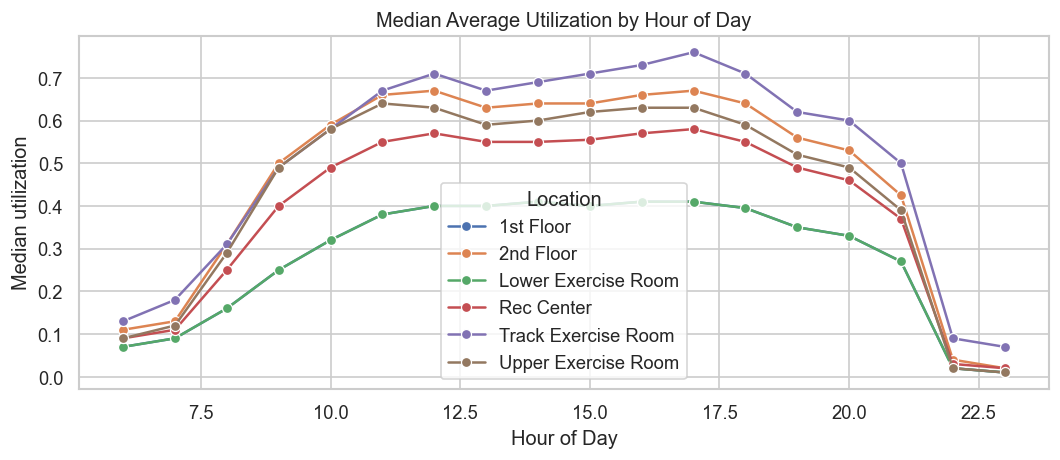

In [6]:
# Visualization 1: utilization by hour of day
plt.figure(figsize=(9, 4))
hourly = df.groupby(['Hour of Day', 'Location'], observed=True)['Average Utilization'].median().reset_index()
sns.lineplot(data=hourly, x='Hour of Day', y='Average Utilization', hue='Location', marker='o')
plt.title('Median Average Utilization by Hour of Day')
plt.ylabel('Median utilization')
plt.tight_layout()
plt.show()

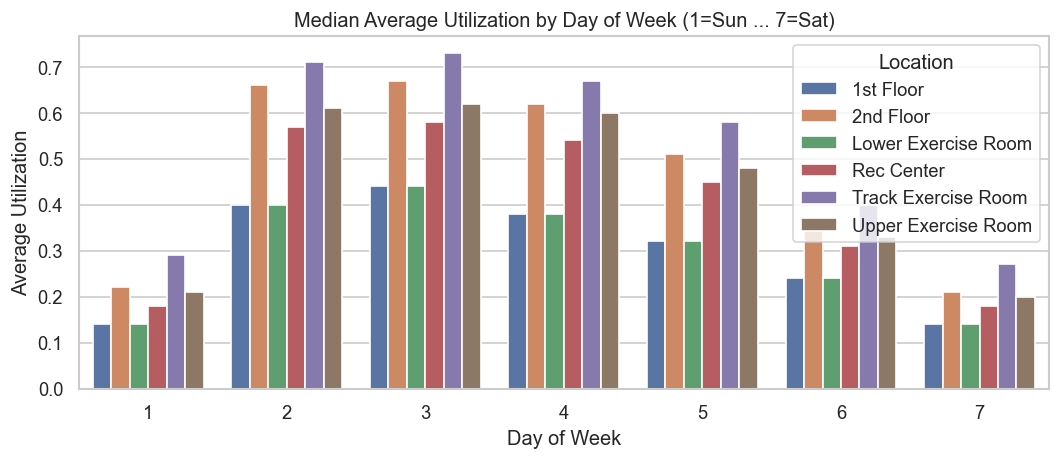

In [7]:
# Visualization 2: utilization by day of week
plt.figure(figsize=(9, 4))
dow = df.groupby(['Day of Week', 'Location'], observed=True)['Average Utilization'].median().reset_index()
sns.barplot(data=dow, x='Day of Week', y='Average Utilization', hue='Location')
plt.title('Median Average Utilization by Day of Week (1=Sun ... 7=Sat)')
plt.tight_layout()
plt.show()

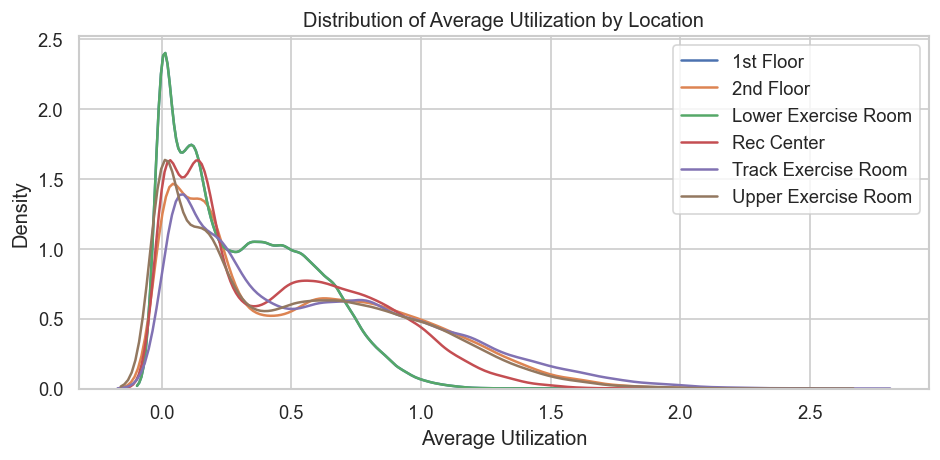

In [8]:
# Visualization 3: distribution of utilization
plt.figure(figsize=(8, 4))
for loc in sorted(df['Location'].dropna().unique()):
    sub = df.loc[df['Location'] == loc, 'Average Utilization'].dropna()
    if len(sub) > 1:
        sns.kdeplot(sub, label=loc)
plt.title('Distribution of Average Utilization by Location')
plt.xlabel('Average Utilization')
plt.legend()
plt.tight_layout()
plt.show()

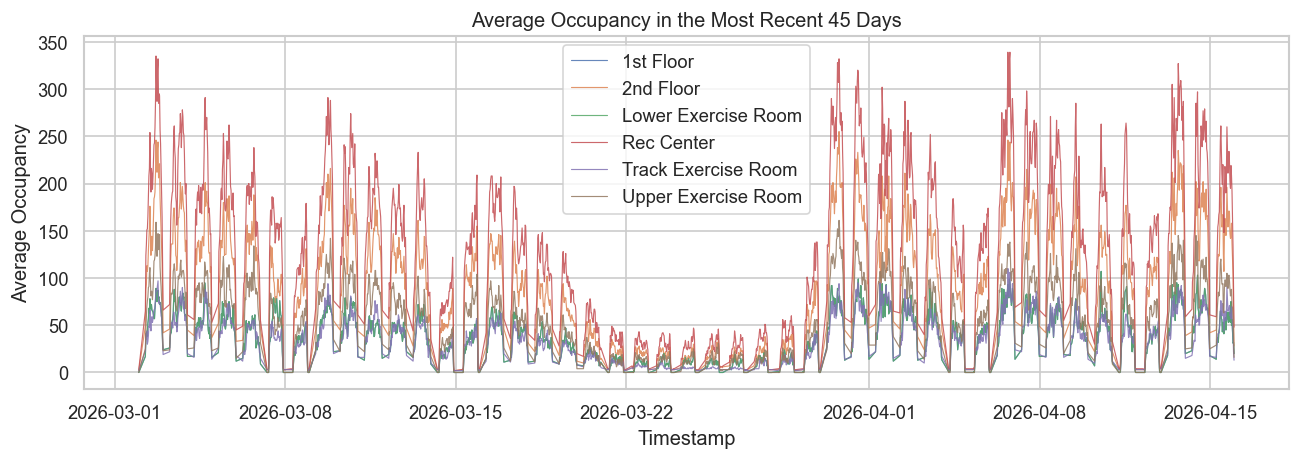

In [9]:
# Visualization 4: recent time-series occupancy
recent_cutoff = df['Timestamp'].max() - pd.Timedelta(days=45)
recent = df[df['Timestamp'] >= recent_cutoff].copy()

plt.figure(figsize=(11, 4))
for loc in sorted(recent['Location'].dropna().unique()):
    loc_series = recent.loc[recent['Location'] == loc].sort_values('Timestamp')
    plt.plot(loc_series['Timestamp'], loc_series['Average Occupancy'], linewidth=0.7, alpha=0.85, label=loc)
plt.title('Average Occupancy in the Most Recent 45 Days')
plt.xlabel('Timestamp')
plt.ylabel('Average Occupancy')
plt.legend()
plt.tight_layout()
plt.show()

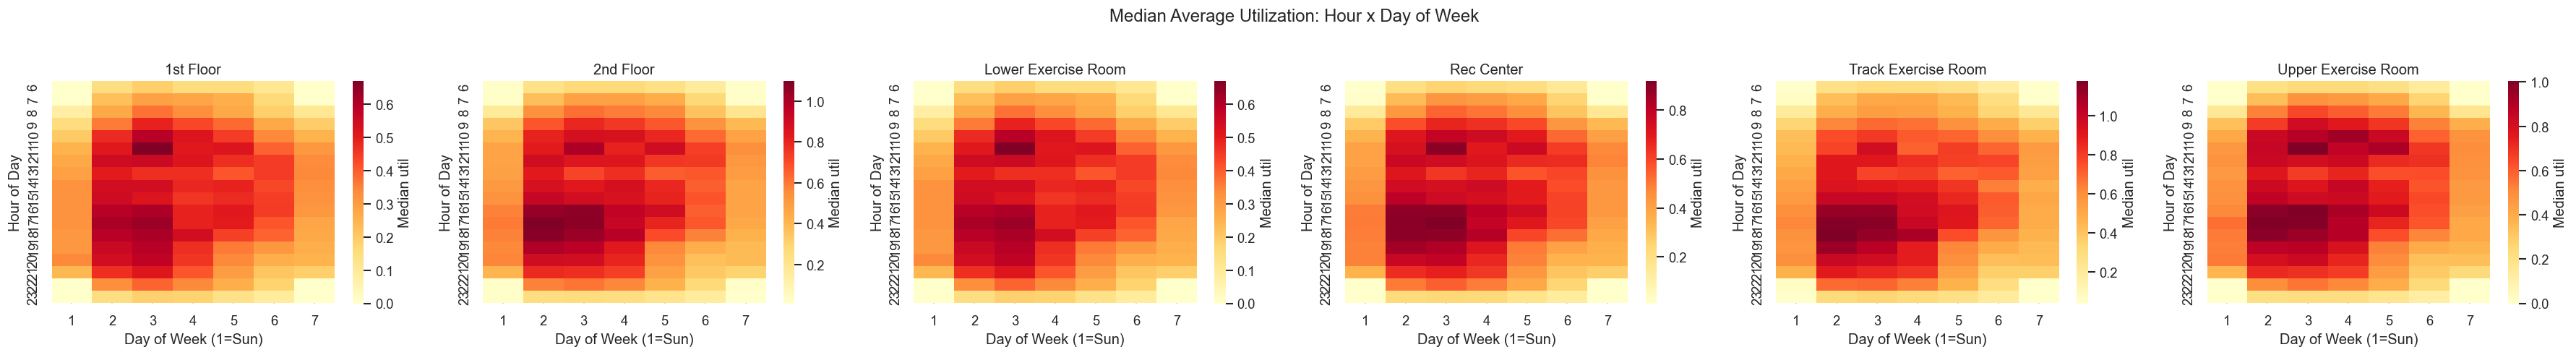

In [10]:
# Visualization 5: heatmap of median utilization (hour x day), by location
locations = sorted(df['Location'].dropna().unique())
fig, axes = plt.subplots(1, len(locations), figsize=(5 * len(locations), 4), squeeze=False)
for ax, loc in zip(axes[0], locations):
    sub = df[df['Location'] == loc]
    pivot = sub.pivot_table(
        values='Average Utilization',
        index='Hour of Day',
        columns='Day of Week',
        aggfunc='median'
    )
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Median util'})
    ax.set_title(loc)
    ax.set_xlabel('Day of Week (1=Sun)')
fig.suptitle('Median Average Utilization: Hour x Day of Week', y=1.02)
plt.tight_layout()
plt.show()

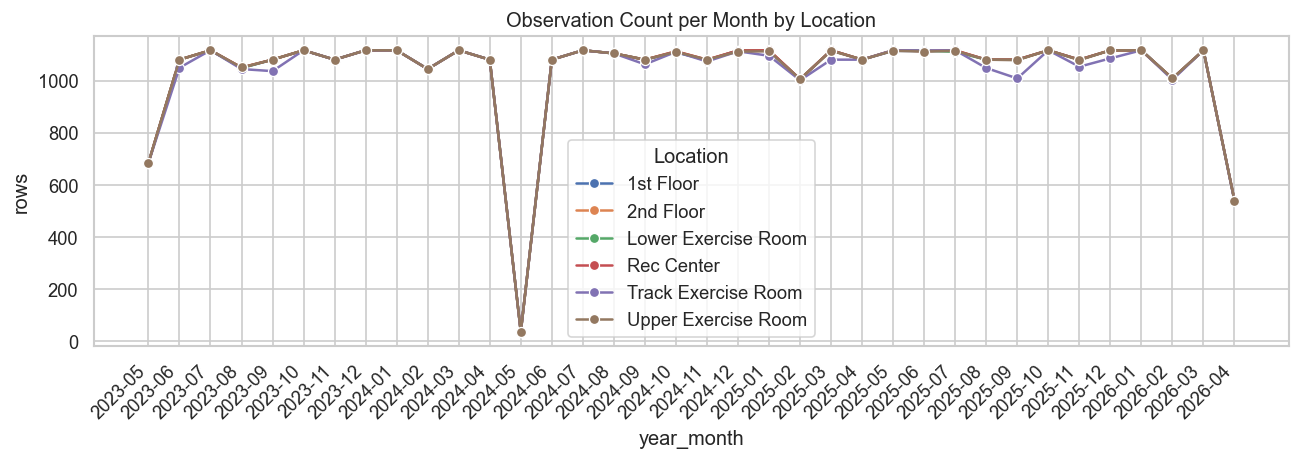

In [11]:
# Visualization 6: monthly row counts (coverage)
monthly = df.assign(year_month=df['Date'].dt.to_period('M').astype(str)) \
    .groupby(['year_month', 'Location']).size().reset_index(name='rows')

plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='year_month', y='rows', hue='Location', marker='o')
plt.title('Observation Count per Month by Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Optional data-quality checks
avg_over_100 = (df['Average Utilization'] > 1.0).sum()
peak_over_100 = (df['Peak Utilization'] > 1.0).sum()

quality = pd.DataFrame({
    'metric': ['avg_util_gt_1_count', 'avg_util_gt_1_pct', 'peak_util_gt_1_count', 'peak_util_gt_1_pct'],
    'value': [
        avg_over_100,
        100 * avg_over_100 / len(df),
        peak_over_100,
        100 * peak_over_100 / len(df),
    ]
})

display(quality)

,metric,value
0,avg_util_gt_1_count,22069.000000
1,avg_util_gt_1_pct,9.874317
2,peak_util_gt_1_count,32141.000000
3,peak_util_gt_1_pct,14.380825


## 5) Proposed Modeling Approach

### Candidate prediction targets
- `Average Occupancy` (count forecast)
- `Average Utilization` (normalized forecast)
- optional classification target: "busy" (e.g., utilization > 0.7)

### Baseline models
1. **Seasonal naive baseline**: predict from same location + same half-hour slot previous week.
2. **Linear model** with time features (`Hour of Day`, `Day of Week`, `Week of Year`) and location effects.

### Stronger models
- **Gradient boosting (XGBoost/LightGBM/CatBoost)** with lag features:
  - lag 1 (previous 30 min), lag 2, lag 48 (previous day same slot), lag 336 (previous week same slot)
  - rolling means (2-hour, 1-day, 1-week)
- Optional **sequence models** (LSTM/Temporal Transformer) if enough time.

### Validation strategy
- Use **time-based split** only (no random shuffle).
- Example: train on earlier periods, validate on later months, test on final held-out window.
- Evaluate with MAE / RMSE (for occupancy), and MAE / MAPE (for utilization).

## 6) Initial Learning Goals for Each Group Member

> Replace names/roles below with your actual team members.

- **Member 1 (Data Engineering):** Build robust ingestion/cleaning pipeline, verify timestamp alignment, and document data dictionary.
- **Member 2 (EDA & Visualization):** Lead descriptive statistics and visual storytelling (daily/weekly/seasonal patterns).
- **Member 3 (Modeling):** Build baselines + one advanced model with lag/rolling features and tune hyperparameters.
- **Member 4 (Evaluation & Reporting):** Design evaluation protocol, compare models, and write conclusions/limitations.

### Team-level goals
- Produce one fully reproducible notebook/script.
- Establish a clean train/validation/test time split.
- Deliver interpretable insights for rec center staffing and facility planning.